In [1]:
from pathlib import Path
import sys
import pandas as pd
import importlib

# Check project root
PROJECT_ROOT = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis")
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "processed"

sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR exists:", SRC_DIR.exists())
print("DATA_DIR exists:", DATA_DIR.exists())

# Check Python utility files
expected_py_files = [
    "image_baseline_utils.py",
    "efficientnet_utils.py",
    "mm_image_utils.py",
]

print("\nPython files:")
for f in expected_py_files:
    path = SRC_DIR / f
    print(f"{f}: {path.exists()} -> {path}")

# Check which files Python imports
import image_baseline_utils
import efficientnet_utils
import mm_image_utils

print("\nImported from:")
print("image_baseline_utils:", image_baseline_utils.__file__)
print("efficientnet_utils:", efficientnet_utils.__file__)
print("mm_image_utils:", mm_image_utils.__file__)

# Correct mixed-all CSVs
TRAIN_CSV = DATA_DIR / "mm_train_mixed_all_group_test.csv"
VAL_CSV   = DATA_DIR / "mm_val_mixed_all_group_test.csv"
TEST_CSV  = DATA_DIR / "mm_test_mixed_all_group_test.csv"

print("\nCSV files:")
for path in [TRAIN_CSV, VAL_CSV, TEST_CSV]:
    print(path.name, "exists:", path.exists(), "->", path)

# Load and inspect columns
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("\nShapes:")
print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

# Check required columns for multimodal image-only model
required_cols = [
    "img_image_path",
    "final_label",
    "combo_type",
    "img_source_dataset",
]

print("\nRequired column check:")
for col in required_cols:
    print(col, ":", col in train_df.columns)

# Check image paths exist
print("\nImage path check:")
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = df.loc[~df["img_image_path"].apply(lambda p: Path(p).exists()), "img_image_path"]
    print(name, "missing image paths:", len(missing))
    if len(missing) > 0:
        print(missing.head())

# Check labels and combo types
print("\nLabel distribution:")
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print("\n", name.upper())
    print(df["final_label"].value_counts())
    print(df["combo_type"].value_counts())

PROJECT_ROOT: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis
SRC_DIR exists: True
DATA_DIR exists: True

Python files:
image_baseline_utils.py: True -> C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src\image_baseline_utils.py
efficientnet_utils.py: True -> C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src\efficientnet_utils.py
mm_image_utils.py: True -> C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src\mm_image_utils.py

Imported from:
image_baseline_utils: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src\image_baseline_utils.py
efficientnet_utils: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src\efficientnet_utils.py
mm_image_utils: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src\mm_image_utils.py

CSV files:
mm_train_mixed_all_group_test.csv exists: True -> C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\mm_train_mixed_all_gro

# ResNet-18 — Image-Only Baseline on Mixed Balanced Multimodal Dataset
## Weighted vs Unweighted Loss Comparison

Runs the model **twice** — once with `pos_weight` (weighted) and once without —
then compares both side by side.

### Why compare?
The mixed balanced dataset has a 1:3 label ratio (legitimate:fraud).
- **Unweighted**: model may over-predict fraud (majority class)
- **Weighted** (`pos_weight=0.33`): penalises fraud misclassification less,
  balances precision/recall trade-off

This mirrors the tabular baseline methodology (none vs class_weight).

### Key diagnostic
`tab1_img0` subgroup F1 — expected near zero for both variants since the
image gives no fraud signal when only the transaction is fraudulent.

## 0 · Imports & reproducibility

In [2]:
import sys, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, auc as sk_auc

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from image_baseline_utils import (
    build_model, unfreeze_backbone,
    fit_model, run_test_evaluation, predict_probs,
    compute_metrics, tune_threshold,
    build_train_transform, build_val_transform, GradCAM,
)
from image_baseline_utils import subgroup_metrics
from mm_image_utils import (
    load_mm_splits, build_mm_dataloaders,
    make_loss_fn, subgroup_by_combo,
)

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

SEED   = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}  |  PyTorch {torch.__version__}")

Device : cpu  |  PyTorch 2.11.0+cpu


## 1 · Paths & config

In [3]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"

TRAIN_CSV = DATA_DIR / "mm_train_mixed_all_group_test.csv"
VAL_CSV   = DATA_DIR / "mm_val_mixed_all_group_test.csv"
TEST_CSV  = DATA_DIR / "mm_test_mixed_all_group_test.csv"

BATCH_SIZE  = 32
NUM_WORKERS = 0

STAGE1_EPOCHS   = 5
STAGE1_LR       = 1e-3
STAGE1_PATIENCE = 5
STAGE2_EPOCHS   = 20
BACKBONE_LR     = 1e-5
HEAD_LR         = 1e-4
STAGE2_PATIENCE = 6

# Results dirs — separate folders so weights never overwrite each other
RESULTS_WEIGHTED   = PROJECT_ROOT / "notebook" / "results" / "mm_image_resnet18_weighted"
RESULTS_UNWEIGHTED = PROJECT_ROOT / "notebook" / "results" / "mm_image_resnet18_unweighted"
RESULTS_WEIGHTED.mkdir(parents=True, exist_ok=True)
RESULTS_UNWEIGHTED.mkdir(parents=True, exist_ok=True)

print("Weighted   results:", RESULTS_WEIGHTED)
print("Unweighted results:", RESULTS_UNWEIGHTED)

Weighted   results: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_resnet18_weighted
Unweighted results: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_image_resnet18_unweighted


## 2 · Load data

In [4]:
train_df, val_df, test_df = load_mm_splits(TRAIN_CSV, VAL_CSV, TEST_CSV)

train_loader, val_loader, test_loader = build_mm_dataloaders(
    train_df, val_df, test_df,
    train_transform=build_train_transform(),
    val_transform=build_val_transform(),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
)
print(f"Batches — train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")

# Loss functions
from torch import nn
loss_fn_weighted   = make_loss_fn(train_df, device)          # pos_weight=0.33
loss_fn_unweighted = nn.BCEWithLogitsLoss().to(device)       # no weighting
print("Loss functions ready.")

train: 7,182 rows | label 0: 2,588 | label 1: 4,594
  combos: {'tab0_img0': 2588, 'tab0_img1': 1866, 'tab1_img1': 1865, 'tab1_img0': 863}
val: 1,508 rows | label 0: 557 | label 1: 951
  combos: {'tab0_img0': 557, 'tab1_img1': 383, 'tab0_img1': 382, 'tab1_img0': 186}
test: 1,474 rows | label 0: 554 | label 1: 920
  combos: {'tab0_img0': 554, 'tab0_img1': 368, 'tab1_img1': 367, 'tab1_img0': 185}
Batches — train:225 val:48 test:47
  pos_weight = 0.563  (n_neg=2588, n_pos=4594)
Loss functions ready.


---
# Part A — Weighted 

## A1 · Stage 1

In [9]:
if (RESULTS_WEIGHTED / "stage1_best.pt").exists():
    print("Stage 1 (this variant) already trained — skipping.")
else:
    model_tmp = build_model(pretrained=True, freeze_backbone=True, dropout=0.3).to(device)
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_tmp.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4,
    )
    model_tmp, h_s1 = fit_model(
        model=model_tmp, train_loader=train_loader, val_loader=val_loader,
        loss_fn=loss_fn_weighted, optimizer=opt1, device=device,
        epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
        monitor_metric="val_roc_auc",
        model_save_path=RESULTS_WEIGHTED / "stage1_best.pt",
    )
    display(h_s1.round(4))

Epoch 01 | lr=1.00e-03 | train_loss=0.3982 | val_loss=0.3518 | val_f1=0.8184 | val_roc_auc=0.8457
  ✓ Saved best model (epoch 1, val_roc_auc=0.8457)
Epoch 02 | lr=1.00e-03 | train_loss=0.3576 | val_loss=0.3369 | val_f1=0.7931 | val_roc_auc=0.8547
  ✓ Saved best model (epoch 2, val_roc_auc=0.8547)
Epoch 03 | lr=1.00e-03 | train_loss=0.3539 | val_loss=0.3305 | val_f1=0.8070 | val_roc_auc=0.8640
  ✓ Saved best model (epoch 3, val_roc_auc=0.8640)
Epoch 04 | lr=1.00e-03 | train_loss=0.3572 | val_loss=0.3232 | val_f1=0.8119 | val_roc_auc=0.8656
  ✓ Saved best model (epoch 4, val_roc_auc=0.8656)
Epoch 05 | lr=1.00e-03 | train_loss=0.3485 | val_loss=0.3462 | val_f1=0.8431 | val_roc_auc=0.8660
  ✓ Saved best model (epoch 5, val_roc_auc=0.8660)
Restored best weights (val_roc_auc=0.8660).


,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.001,0.3982,0.3518,0.7772,0.8420,0.7960,0.8184,0.8457
1,2,0.001,0.3576,0.3369,0.7599,0.8686,0.7298,0.7931,0.8547
2,3,0.001,0.3539,0.3305,0.7745,0.8767,0.7476,0.8070,0.8640
3,4,0.001,0.3572,0.3232,0.7785,0.8739,0.7581,0.8119,0.8656
4,5,0.001,0.3485,0.3462,0.7984,0.8278,0.8591,0.8431,0.8660


## A2 · Stage 2

In [10]:
if (RESULTS_WEIGHTED / "stage2_best.pt").exists():
    print("Stage 2 (this variant) already trained — skipping.")
else:
    model_tmp = build_model(pretrained=False, freeze_backbone=False, dropout=0.3).to(device)
    model_tmp.load_state_dict(torch.load(RESULTS_WEIGHTED / "stage1_best.pt", map_location=device))
    unfreeze_backbone(model_tmp)
    bp = [p for n, p in model_tmp.named_parameters() if "fc" not in n]
    hp = list(model_tmp.fc.parameters())
    opt2 = torch.optim.Adam([{"params":bp,"lr":BACKBONE_LR},{"params":hp,"lr":HEAD_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    model_tmp, h_s2 = fit_model(
        model=model_tmp, train_loader=train_loader, val_loader=val_loader,
        loss_fn=loss_fn_weighted, optimizer=opt2, device=device,
        epochs=STAGE2_EPOCHS, early_stopping_patience=STAGE2_PATIENCE,
        monitor_metric="val_roc_auc", scheduler=sched,
        model_save_path=RESULTS_WEIGHTED / "stage2_best.pt",
    )
    hist = pd.concat([h_s1, h_s2], ignore_index=True)
    hist["epoch"] = range(1, len(hist)+1)
    hist.to_csv(RESULTS_WEIGHTED / "training_history.csv", index=False)
    display(h_s2.round(4))

Backbone unfrozen — all parameters now trainable.
Epoch 01 | lr=1.00e-05 | train_loss=0.3326 | val_loss=0.3065 | val_f1=0.8469 | val_roc_auc=0.8777
  ✓ Saved best model (epoch 1, val_roc_auc=0.8777)
Epoch 02 | lr=9.94e-06 | train_loss=0.3082 | val_loss=0.2967 | val_f1=0.8404 | val_roc_auc=0.8794
  ✓ Saved best model (epoch 2, val_roc_auc=0.8794)
Epoch 03 | lr=9.76e-06 | train_loss=0.3096 | val_loss=0.2996 | val_f1=0.8507 | val_roc_auc=0.8774
Epoch 04 | lr=9.46e-06 | train_loss=0.3031 | val_loss=0.2935 | val_f1=0.8470 | val_roc_auc=0.8766
Epoch 05 | lr=9.05e-06 | train_loss=0.2932 | val_loss=0.2909 | val_f1=0.8389 | val_roc_auc=0.8790
Epoch 06 | lr=8.55e-06 | train_loss=0.2898 | val_loss=0.2927 | val_f1=0.8398 | val_roc_auc=0.8772
Epoch 07 | lr=7.96e-06 | train_loss=0.2892 | val_loss=0.2897 | val_f1=0.8490 | val_roc_auc=0.8782
Epoch 08 | lr=7.30e-06 | train_loss=0.2846 | val_loss=0.2901 | val_f1=0.8447 | val_roc_auc=0.8772
Early stopping at epoch 8 (patience=6).
Restored best weights (v

,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.0,0.3326,0.3065,0.8156,0.8890,0.8086,0.8469,0.8777
1,2,0.0,0.3082,0.2967,0.8123,0.9063,0.7834,0.8404,0.8794
2,3,0.0,0.3096,0.2996,0.8210,0.8973,0.8086,0.8507,0.8774
3,4,0.0,0.3031,0.2935,0.8203,0.9146,0.7886,0.8470,0.8766
4,5,0.0,0.2932,0.2909,0.8123,0.9144,0.7750,0.8389,0.8790
5,6,0.0,0.2898,0.2927,0.8130,0.9135,0.7771,0.8398,0.8772
6,7,0.0,0.2892,0.2897,0.8216,0.9108,0.7950,0.8490,0.8782
7,8,0.0,0.2846,0.2901,0.8183,0.9164,0.7834,0.8447,0.8772


## A3 · Load saved model

In [11]:
model_w = build_model(pretrained=False, freeze_backbone=False, dropout=0.3).to(device)
model_w.load_state_dict(torch.load(RESULTS_WEIGHTED / "stage2_best.pt", map_location=device))
model_w.eval()
history_w = pd.read_csv(RESULTS_WEIGHTED / "training_history.csv")

model_u = build_model(pretrained=False, freeze_backbone=False, dropout=0.3).to(device)
model_u.load_state_dict(torch.load(RESULTS_UNWEIGHTED / "stage2_best.pt", map_location=device))
model_u.eval()
history_u = pd.read_csv(RESULTS_UNWEIGHTED / "training_history.csv")
print("Both models loaded.")

Both models loaded.


## A4 · Training curves

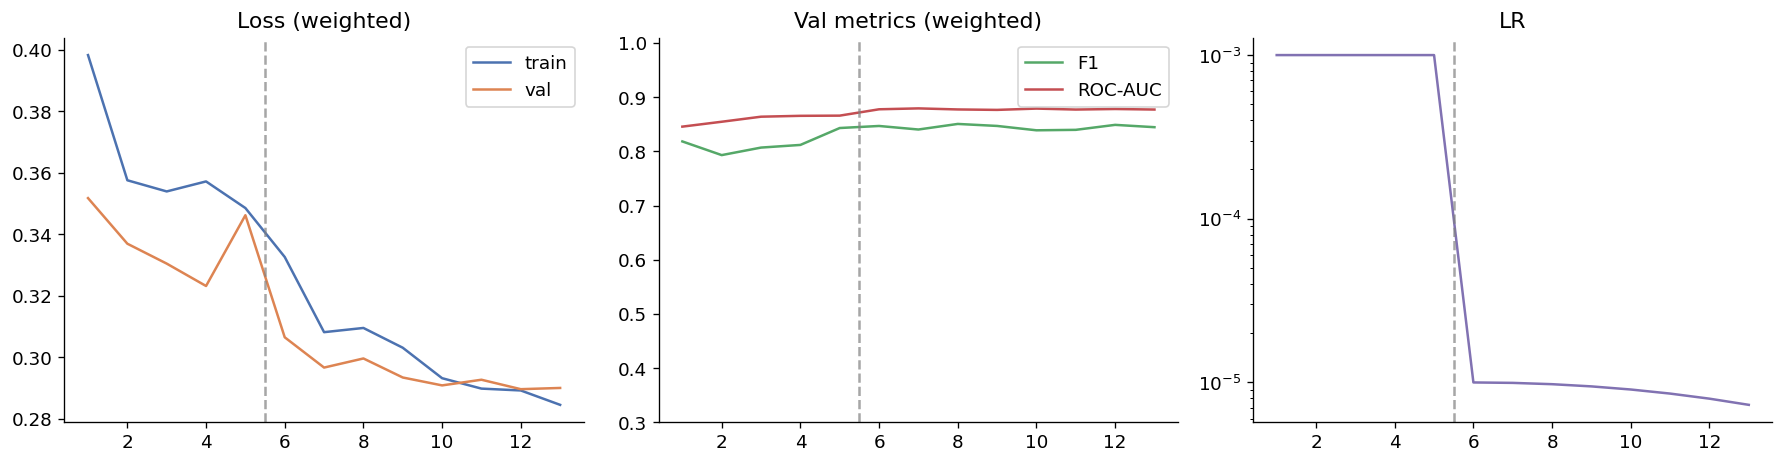

In [12]:
if "epoch_global" not in history_w.columns:
    history_w["epoch_global"] = range(1, len(history_w) + 1)
n_s1 = (history_w["epoch"] <= STAGE1_EPOCHS).sum()
ep   = history_w["epoch_global"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ep, history_w["train_loss"], label="train", color="#4C72B0")
axes[0].plot(ep, history_w["val_loss"],   label="val",   color="#DD8452")
axes[0].set_title("Loss (weighted)"); axes[0].legend()
axes[1].plot(ep, history_w["val_f1"],      label="F1",      color="#55A868")
axes[1].plot(ep, history_w["val_roc_auc"], label="ROC-AUC", color="#C44E52")
axes[1].set_ylim(0.3, 1.01); axes[1].set_title("Val metrics (weighted)"); axes[1].legend()
axes[2].plot(ep, history_w["lr"], color="#8172B2")
axes[2].set_title("LR"); axes[2].set_yscale("log")
for ax in axes:
    ax.axvline(x=n_s1+0.5, color="gray", linestyle="--", alpha=0.7)
    ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## A5 · Threshold tuning & test evaluation

In [13]:
val_y_true, val_y_prob = predict_probs(model_w, val_loader, device)
thresh_w, sweep_w = tune_threshold(val_y_true, val_y_prob, metric="f1")
sweep_w.to_csv(RESULTS_WEIGHTED / "threshold_sweep.csv", index=False)

metrics_w = run_test_evaluation(
    model=model_w, test_loader=test_loader,
    loss_fn=loss_fn_weighted, device=device, threshold=thresh_w,
)
y_true_w, y_prob_w = predict_probs(model_w, test_loader, device)
pred_w = test_df.reset_index(drop=True).copy()
pred_w["y_true"] = y_true_w
pred_w["y_prob"] = y_prob_w
pred_w["y_pred"] = (pred_w["y_prob"] >= thresh_w).astype(int)
pred_w.to_csv(RESULTS_WEIGHTED / "test_predictions.csv", index=False)

sg_w = subgroup_by_combo(pred_w, thresh_w)
sg_w.to_csv(RESULTS_WEIGHTED / "subgroup_combo_type.csv", index=False)
display(sg_w.round(3))


Best threshold (f1): 0.35

── TEST METRICS ──────────────────────────────
  loss        : 0.2895
  accuracy    : 0.8331
  precision   : 0.8955
  recall      : 0.8293
  f1          : 0.8612
  roc_auc     : 0.8821
  confusion_matrix:
[[465  89]
 [157 763]]
──────────────────────────────────────────────


,combo_type,n_rows,label,precision,recall,f1,roc_auc
0,tab0_img0,554,0,0.0,0.000,0.000,NaN
1,tab0_img1,368,1,1.0,0.986,0.993,NaN
2,tab1_img0,185,1,1.0,0.205,0.341,NaN
3,tab1_img1,367,1,1.0,0.986,0.993,NaN


---
# Part B — Unweighted (no `pos_weight`)

## B1 · Stage 1

In [ ]:
if (RESULTS_UNWEIGHTED / "stage1_best.pt").exists():
    print("Stage 1 (this variant) already trained — skipping.")
    h_s1 = None

else:
    model_tmp = build_model(pretrained=True, freeze_backbone=True, dropout=0.3).to(device)
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_tmp.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4,
    )
    model_tmp, h_s1 = fit_model(
        model=model_tmp, train_loader=train_loader, val_loader=val_loader,
        loss_fn=loss_fn_unweighted, optimizer=opt1, device=device,
        epochs=STAGE1_EPOCHS, early_stopping_patience=STAGE1_PATIENCE,
        monitor_metric="val_roc_auc",
        model_save_path=RESULTS_UNWEIGHTED / "stage1_best.pt",
    )
    display(h_s1.round(4))

Epoch 01 | lr=1.00e-03 | train_loss=0.5277 | val_loss=0.4935 | val_f1=0.8350 | val_roc_auc=0.8355
  ✓ Saved best model (epoch 1, val_roc_auc=0.8355)
Epoch 02 | lr=1.00e-03 | train_loss=0.4821 | val_loss=0.4582 | val_f1=0.8251 | val_roc_auc=0.8521
  ✓ Saved best model (epoch 2, val_roc_auc=0.8521)
Epoch 03 | lr=1.00e-03 | train_loss=0.4758 | val_loss=0.4478 | val_f1=0.8327 | val_roc_auc=0.8591
  ✓ Saved best model (epoch 3, val_roc_auc=0.8591)
Epoch 04 | lr=1.00e-03 | train_loss=0.4695 | val_loss=0.4434 | val_f1=0.8378 | val_roc_auc=0.8616
  ✓ Saved best model (epoch 4, val_roc_auc=0.8616)
Epoch 05 | lr=1.00e-03 | train_loss=0.4667 | val_loss=0.4955 | val_f1=0.8298 | val_roc_auc=0.8607
Restored best weights (val_roc_auc=0.8616).


,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.001,0.5277,0.4935,0.7785,0.7875,0.8885,0.8350,0.8355
1,2,0.001,0.4821,0.4582,0.7805,0.8291,0.8212,0.8251,0.8521
2,3,0.001,0.4758,0.4478,0.7885,0.8305,0.8349,0.8327,0.8591
3,4,0.001,0.4695,0.4434,0.7931,0.8284,0.8475,0.8378,0.8616
4,5,0.001,0.4667,0.4955,0.7633,0.7592,0.9148,0.8298,0.8607


## B2 · Stage 2

In [7]:
if (RESULTS_UNWEIGHTED / "stage2_best.pt").exists():
    print("Stage 2 (this variant) already trained — skipping.")
else:
    model_tmp = build_model(pretrained=False, freeze_backbone=False, dropout=0.3).to(device)
    model_tmp.load_state_dict(torch.load(RESULTS_UNWEIGHTED / "stage1_best.pt", map_location=device))
    unfreeze_backbone(model_tmp)
    bp = [p for n, p in model_tmp.named_parameters() if "fc" not in n]
    hp = list(model_tmp.fc.parameters())
    opt2 = torch.optim.Adam([{"params":bp,"lr":BACKBONE_LR},{"params":hp,"lr":HEAD_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    model_tmp, h_s2 = fit_model(
        model=model_tmp, train_loader=train_loader, val_loader=val_loader,
        loss_fn=loss_fn_unweighted, optimizer=opt2, device=device,
        epochs=STAGE2_EPOCHS, early_stopping_patience=STAGE2_PATIENCE,
        monitor_metric="val_roc_auc", scheduler=sched,
        model_save_path=RESULTS_UNWEIGHTED / "stage2_best.pt",
    )
    hist = pd.concat([h_s1, h_s2], ignore_index=True) if h_s1 is not None else h_s2.copy()
    hist["epoch"] = range(1, len(hist)+1)
    hist.to_csv(RESULTS_UNWEIGHTED / "training_history.csv", index=False)
    display(h_s2.round(4))

Backbone unfrozen — all parameters now trainable.
Epoch 01 | lr=1.00e-05 | train_loss=0.4429 | val_loss=0.4137 | val_f1=0.8567 | val_roc_auc=0.8749
  ✓ Saved best model (epoch 1, val_roc_auc=0.8749)
Epoch 02 | lr=9.94e-06 | train_loss=0.4194 | val_loss=0.4098 | val_f1=0.8568 | val_roc_auc=0.8737
Epoch 03 | lr=9.76e-06 | train_loss=0.4103 | val_loss=0.4034 | val_f1=0.8575 | val_roc_auc=0.8750
  ✓ Saved best model (epoch 3, val_roc_auc=0.8750)
Epoch 04 | lr=9.46e-06 | train_loss=0.4032 | val_loss=0.4099 | val_f1=0.8574 | val_roc_auc=0.8756
  ✓ Saved best model (epoch 4, val_roc_auc=0.8756)
Epoch 05 | lr=9.05e-06 | train_loss=0.4036 | val_loss=0.4033 | val_f1=0.8596 | val_roc_auc=0.8739
Epoch 06 | lr=8.55e-06 | train_loss=0.3941 | val_loss=0.4037 | val_f1=0.8607 | val_roc_auc=0.8710
Epoch 07 | lr=7.96e-06 | train_loss=0.3930 | val_loss=0.3996 | val_f1=0.8605 | val_roc_auc=0.8762
  ✓ Saved best model (epoch 7, val_roc_auc=0.8762)
Epoch 08 | lr=7.30e-06 | train_loss=0.3870 | val_loss=0.4031

,epoch,lr,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.0,0.4429,0.4137,0.8223,0.8716,0.8423,0.8567,0.8749
1,2,0.0,0.4194,0.4098,0.8236,0.8776,0.8370,0.8568,0.8737
2,3,0.0,0.4103,0.4034,0.8263,0.8884,0.8286,0.8575,0.8750
3,4,0.0,0.4032,0.4099,0.8229,0.8709,0.8444,0.8574,0.8756
4,5,0.0,0.4036,0.4033,0.8282,0.8870,0.8339,0.8596,0.8739
5,6,0.0,0.3941,0.4037,0.8276,0.8776,0.8444,0.8607,0.8710
6,7,0.0,0.3930,0.3996,0.8282,0.8819,0.8402,0.8605,0.8762
7,8,0.0,0.3870,0.4031,0.8223,0.8939,0.8149,0.8526,0.8762
8,9,0.0,0.3883,0.4006,0.8302,0.8891,0.8349,0.8612,0.8755
9,10,0.0,0.3803,0.3966,0.8276,0.8869,0.8328,0.8590,0.8766


## B3 · Load saved model

In [14]:
model_w = build_model(pretrained=False, freeze_backbone=False, dropout=0.3).to(device)
model_w.load_state_dict(torch.load(RESULTS_WEIGHTED / "stage2_best.pt", map_location=device))
model_w.eval()
history_w = pd.read_csv(RESULTS_WEIGHTED / "training_history.csv")

model_u = build_model(pretrained=False, freeze_backbone=False, dropout=0.3).to(device)
model_u.load_state_dict(torch.load(RESULTS_UNWEIGHTED / "stage2_best.pt", map_location=device))
model_u.eval()
history_u = pd.read_csv(RESULTS_UNWEIGHTED / "training_history.csv")
print("Both models loaded.")

Both models loaded.


## B4 · Training curves

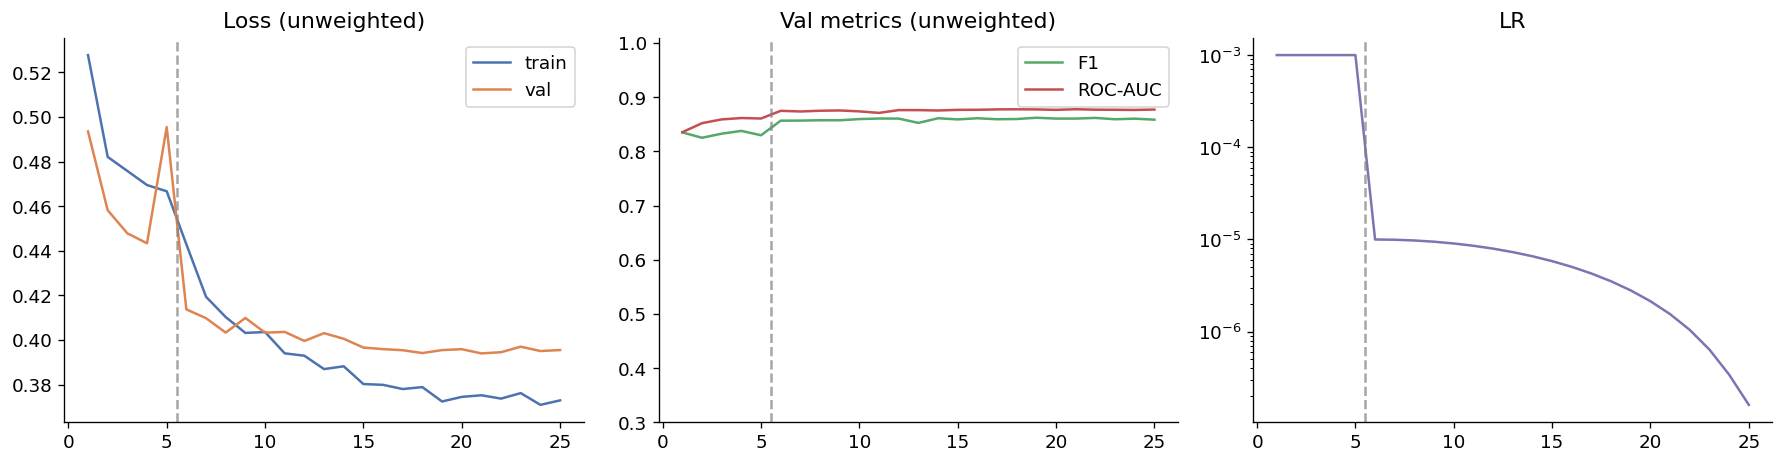

In [15]:
if "epoch_global" not in history_u.columns:
    history_u["epoch_global"] = range(1, len(history_u) + 1)
n_s1 = (history_u["epoch"] <= STAGE1_EPOCHS).sum()
ep   = history_u["epoch_global"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ep, history_u["train_loss"], label="train", color="#4C72B0")
axes[0].plot(ep, history_u["val_loss"],   label="val",   color="#DD8452")
axes[0].set_title("Loss (unweighted)"); axes[0].legend()
axes[1].plot(ep, history_u["val_f1"],      label="F1",      color="#55A868")
axes[1].plot(ep, history_u["val_roc_auc"], label="ROC-AUC", color="#C44E52")
axes[1].set_ylim(0.3, 1.01); axes[1].set_title("Val metrics (unweighted)"); axes[1].legend()
axes[2].plot(ep, history_u["lr"], color="#8172B2")
axes[2].set_title("LR"); axes[2].set_yscale("log")
for ax in axes:
    ax.axvline(x=n_s1+0.5, color="gray", linestyle="--", alpha=0.7)
    ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_UNWEIGHTED / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## B5 · Threshold tuning & test evaluation

In [16]:
val_y_true, val_y_prob = predict_probs(model_u, val_loader, device)
thresh_u, sweep_u = tune_threshold(val_y_true, val_y_prob, metric="f1")
sweep_u.to_csv(RESULTS_UNWEIGHTED / "threshold_sweep.csv", index=False)

metrics_u = run_test_evaluation(
    model=model_u, test_loader=test_loader,
    loss_fn=loss_fn_unweighted, device=device, threshold=thresh_u,
)
y_true_u, y_prob_u = predict_probs(model_u, test_loader, device)
pred_u = test_df.reset_index(drop=True).copy()
pred_u["y_true"] = y_true_u
pred_u["y_prob"] = y_prob_u
pred_u["y_pred"] = (pred_u["y_prob"] >= thresh_u).astype(int)
pred_u.to_csv(RESULTS_UNWEIGHTED / "test_predictions.csv", index=False)

sg_u = subgroup_by_combo(pred_u, thresh_u)
sg_u.to_csv(RESULTS_UNWEIGHTED / "subgroup_combo_type.csv", index=False)
display(sg_u.round(3))


Best threshold (f1): 0.45

── TEST METRICS ──────────────────────────────
  loss        : 0.3881
  accuracy    : 0.8318
  precision   : 0.8889
  recall      : 0.8348
  f1          : 0.8610
  roc_auc     : 0.8831
  confusion_matrix:
[[458  96]
 [152 768]]
──────────────────────────────────────────────


,combo_type,n_rows,label,precision,recall,f1,roc_auc
0,tab0_img0,554,0,0.0,0.000,0.000,NaN
1,tab0_img1,368,1,1.0,1.000,1.000,NaN
2,tab1_img0,185,1,1.0,0.178,0.303,NaN
3,tab1_img1,367,1,1.0,1.000,1.000,NaN


---
# Part C — Weighted vs Unweighted comparison

## C1 · Overall metrics

,variant,threshold,accuracy,precision,recall,f1,roc_auc
0,Weighted,0.35,0.8331,0.8955,0.8293,0.8612,0.8821
1,Unweighted,0.45,0.8318,0.8889,0.8348,0.8610,0.8831


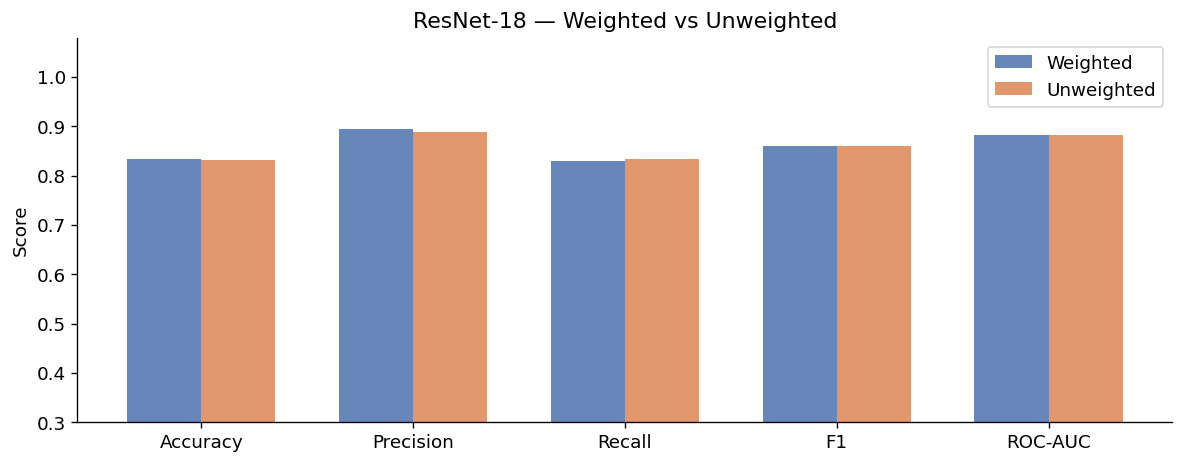

In [17]:
cmp = pd.DataFrame([
    {"variant": "Weighted",   "threshold": thresh_w,
     "accuracy": metrics_w["accuracy"], "precision": metrics_w["precision"],
     "recall":   metrics_w["recall"],   "f1":        metrics_w["f1"],
     "roc_auc":  metrics_w["roc_auc"]},
    {"variant": "Unweighted", "threshold": thresh_u,
     "accuracy": metrics_u["accuracy"], "precision": metrics_u["precision"],
     "recall":   metrics_u["recall"],   "f1":        metrics_u["f1"],
     "roc_auc":  metrics_u["roc_auc"]},
])
display(cmp.round(4))
cmp.to_csv(RESULTS_WEIGHTED.parent / "mm_image_resnet18_weighted_vs_unweighted.csv", index=False)

metrics_plot = ["accuracy","precision","recall","f1","roc_auc"]
x = np.arange(len(metrics_plot)); width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x-width/2, cmp[cmp["variant"]=="Weighted"][metrics_plot].values[0],
       width, label="Weighted",   color="#4C72B0", alpha=0.85)
ax.bar(x+width/2, cmp[cmp["variant"]=="Unweighted"][metrics_plot].values[0],
       width, label="Unweighted", color="#DD8452", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(["Accuracy","Precision","Recall","F1","ROC-AUC"])
ax.set_ylim(0.3, 1.08); ax.set_title("ResNet-18 — Weighted vs Unweighted")
ax.set_ylabel("Score"); ax.legend()
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED.parent / "mm_image_resnet18_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## C2 · ROC curves comparison

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
fpr_w, tpr_w, _ = roc_curve(y_true_w, y_prob_w)
fpr_u, tpr_u, _ = roc_curve(y_true_u, y_prob_u)
ax.plot(fpr_w, tpr_w, color="#4C72B0", lw=2,
        label=f"Weighted   AUC={sk_auc(fpr_w,tpr_w):.4f}")
ax.plot(fpr_u, tpr_u, color="#DD8452", lw=2,
        label=f"Unweighted AUC={sk_auc(fpr_u,tpr_u):.4f}")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curve comparison"); ax.legend()
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED.parent / f"{results_base}_roc_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'results_base' is not defined

## C3 · Combo subgroup comparison
The most important comparison — does weighting help on `tab1_img0`?

In [20]:
COMBO_COLOURS = {"tab0_img0":"#4C72B0","tab1_img1":"#C44E52",
                 "tab1_img0":"#DD8452","tab0_img1":"#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (sg, label) in zip(axes, [(sg_w,"Weighted"),(sg_u,"Unweighted")]):
    colours = [COMBO_COLOURS.get(c,"gray") for c in sg["combo_type"]]
    bars = ax.bar(sg["combo_type"], sg["f1"],
                  color=colours, edgecolor="white", width=0.5)
    for bar, val in zip(bars, sg["f1"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0,1.15); ax.set_title(f"F1 by combo — {label}")
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4)
    ax.set_ylabel("F1"); ax.tick_params(axis="x", rotation=15)
    ax.spines[["top","right"]].set_visible(False)

fig.legend(handles=[
    Patch(color="#4C72B0",label="tab0_img0 → label 0"),
    Patch(color="#C44E52",label="tab1_img1 → label 1 (both)"),
    Patch(color="#DD8452",label="tab1_img0 → label 1 (tab only)"),
    Patch(color="#55A868",label="tab0_img1 → label 1 (img only)"),
], loc="lower center", ncol=4, bbox_to_anchor=(0.5,-0.12), fontsize=9)
fig.suptitle("Combo subgroup F1 — Weighted vs Unweighted", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED.parent / f"{results_base}_combo_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'results_base' is not defined

## C4 · Score distributions

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (y_true, y_prob, thresh, label) in zip(axes, [
    (y_true_w, y_prob_w, thresh_w, "Weighted"),
    (y_true_u, y_prob_u, thresh_u, "Unweighted"),
]):
    ax.hist(y_prob[y_true==0], bins=40, alpha=0.65, color="#4C72B0",
            label="Legitimate", density=True)
    ax.hist(y_prob[y_true==1], bins=40, alpha=0.65, color="#DD8452",
            label="Fraud",      density=True)
    ax.axvline(x=thresh, color="red", linestyle="--", label=f"t={thresh:.2f}")
    ax.set_xlabel("Predicted fraud probability")
    ax.set_title(f"Score distribution — {label}")
    ax.legend(fontsize=8); ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED.parent / f"{results_base}_score_dist_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'results_base' is not defined

## C5 · Summary table

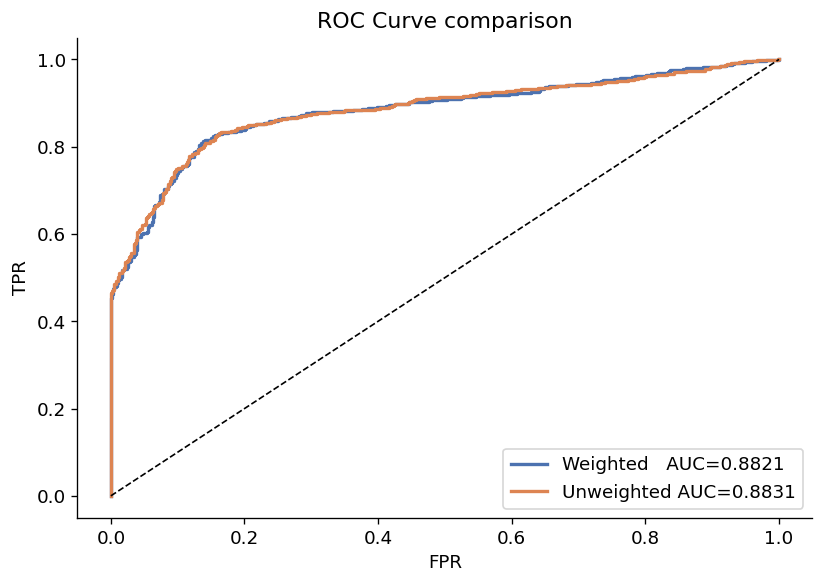

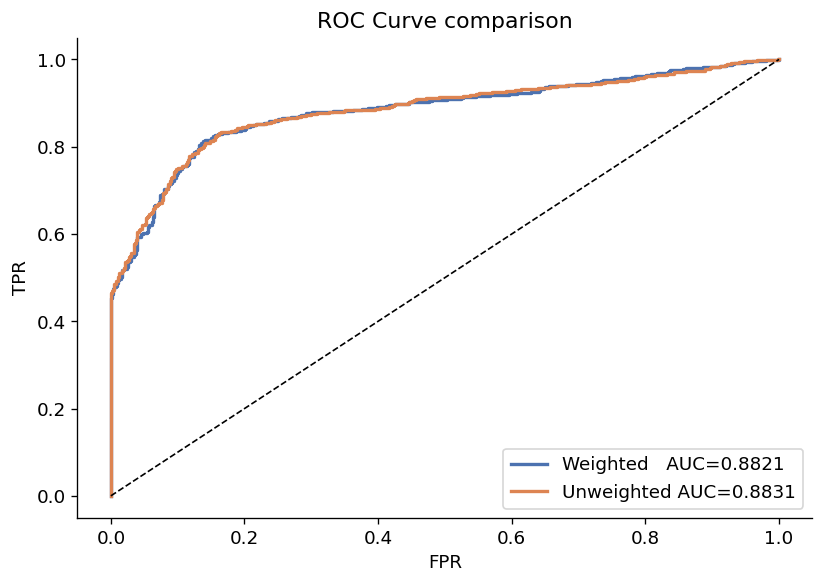

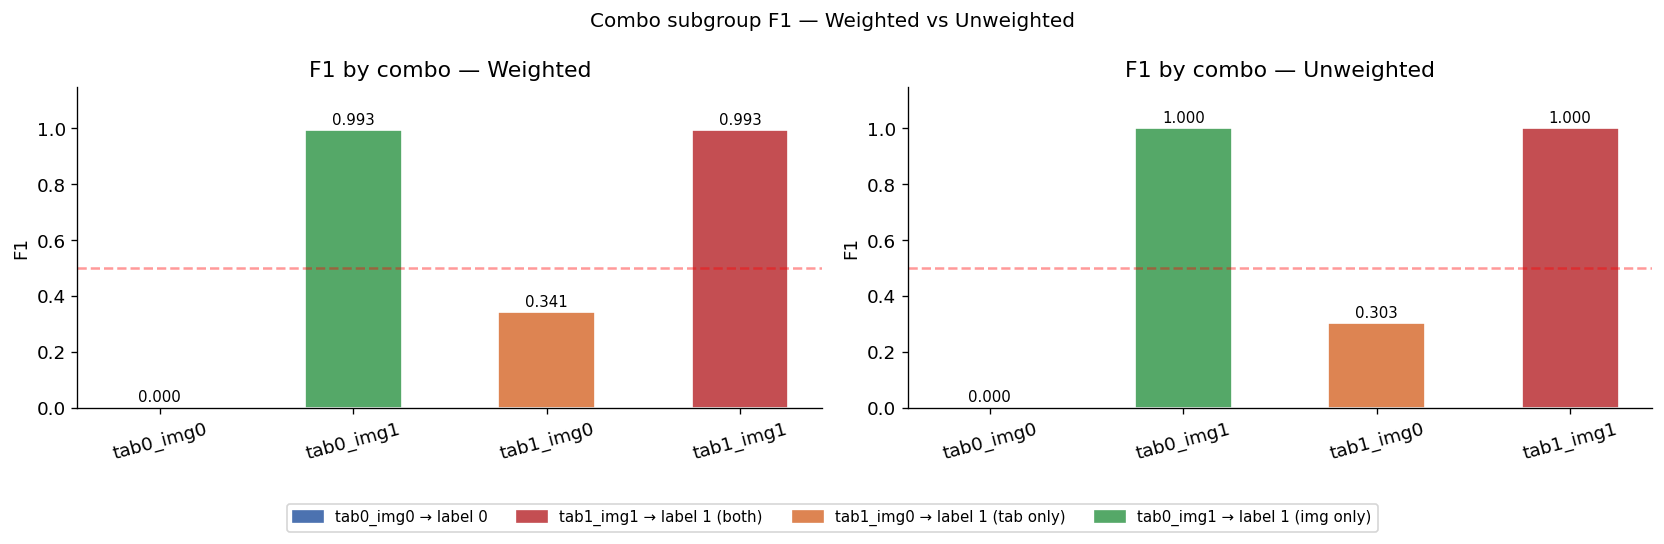

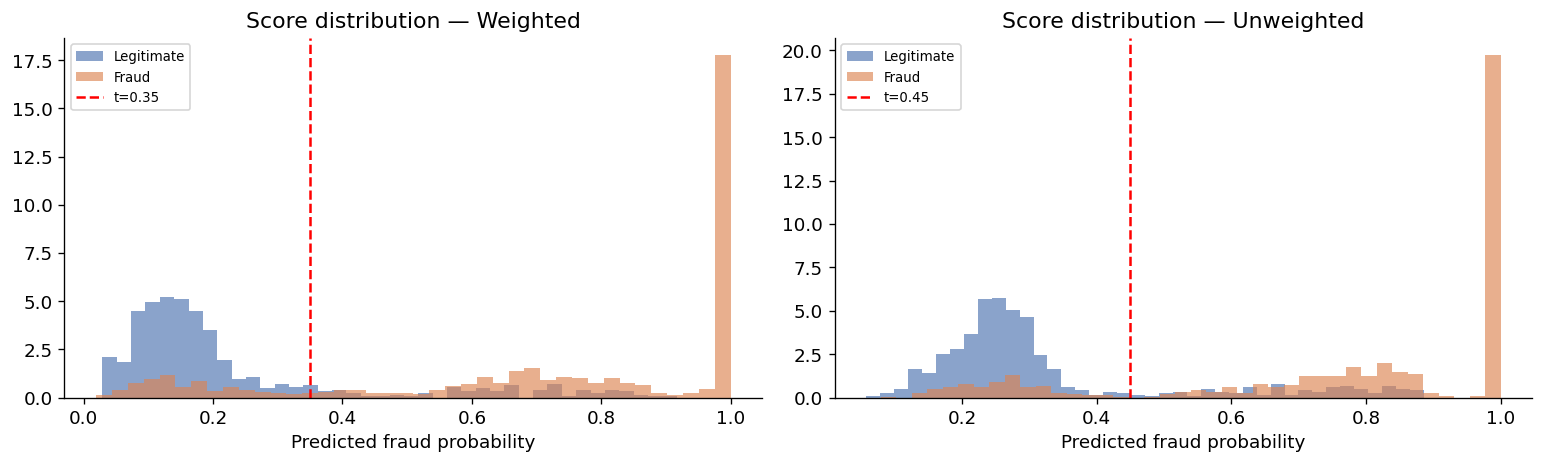

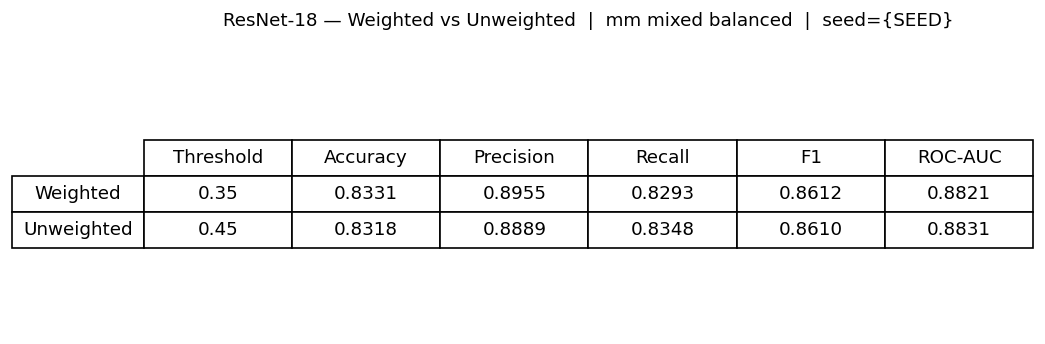

All results saved.


In [22]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")
col_labels = ["Threshold","Accuracy","Precision","Recall","F1","ROC-AUC"]
cell_data  = [
    [f"{thresh_w:.2f}",
     f"{metrics_w['accuracy']:.4f}", f"{metrics_w['precision']:.4f}",
     f"{metrics_w['recall']:.4f}",   f"{metrics_w['f1']:.4f}",
     f"{metrics_w['roc_auc']:.4f}"],
    [f"{thresh_u:.2f}",
     f"{metrics_u['accuracy']:.4f}", f"{metrics_u['precision']:.4f}",
     f"{metrics_u['recall']:.4f}",   f"{metrics_u['f1']:.4f}",
     f"{metrics_u['roc_auc']:.4f}"],
]
tbl = ax.table(cellText=cell_data,
               rowLabels=["Weighted","Unweighted"],
               colLabels=col_labels,
               cellLoc="center", rowLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 1.8)
ax.set_title("ResNet-18 — Weighted vs Unweighted  |  mm mixed balanced  |  seed={SEED}",
             fontsize=11, pad=18)
fig.tight_layout()
fig.savefig(RESULTS_WEIGHTED.parent / "mm_image_resnet18_final_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("All results saved.")